**Importing Libraries**


In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


**Loading Dataset**


In [26]:
os.chdir ('C:\\Users\\Admin\\Desktop\\Saad\\ML Internship\\Drive\\ML Aug 25 Day 21 Projects\\PRJ Cancer Prediction\\')
data = pd.read_csv('data.csv')
print(f"Dataset loaded: {data.shape[0]} samples, {data.shape[1]} features")
data.head()

Dataset loaded: 569 samples, 32 features


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Displaying Shape**

In [3]:
display(data.shape)

(569, 32)

**Displaying Info**

In [4]:
df = data.copy()
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perim

**Target Distribution**

In [5]:
print("Target Distribution:")
display(df['diagnosis'].value_counts())
display(df['diagnosis'].value_counts(normalize=True) * 100)


Target Distribution:


diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

**Preprocessing**

In [6]:
# Remove unnecessary columns
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)
df = df.drop(['id'], axis=1)

# Encode diagnosis: M=1, B=0
label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])

# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print(f"Features: {X.shape[1]}, Target: Benign (0) and Malignant (1)")
print(f"Target distribution after encoding:\n{y.value_counts()}")


Features: 30, Target: Benign (0) and Malignant (1)
Target distribution after encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


**Correlation Heatmap**

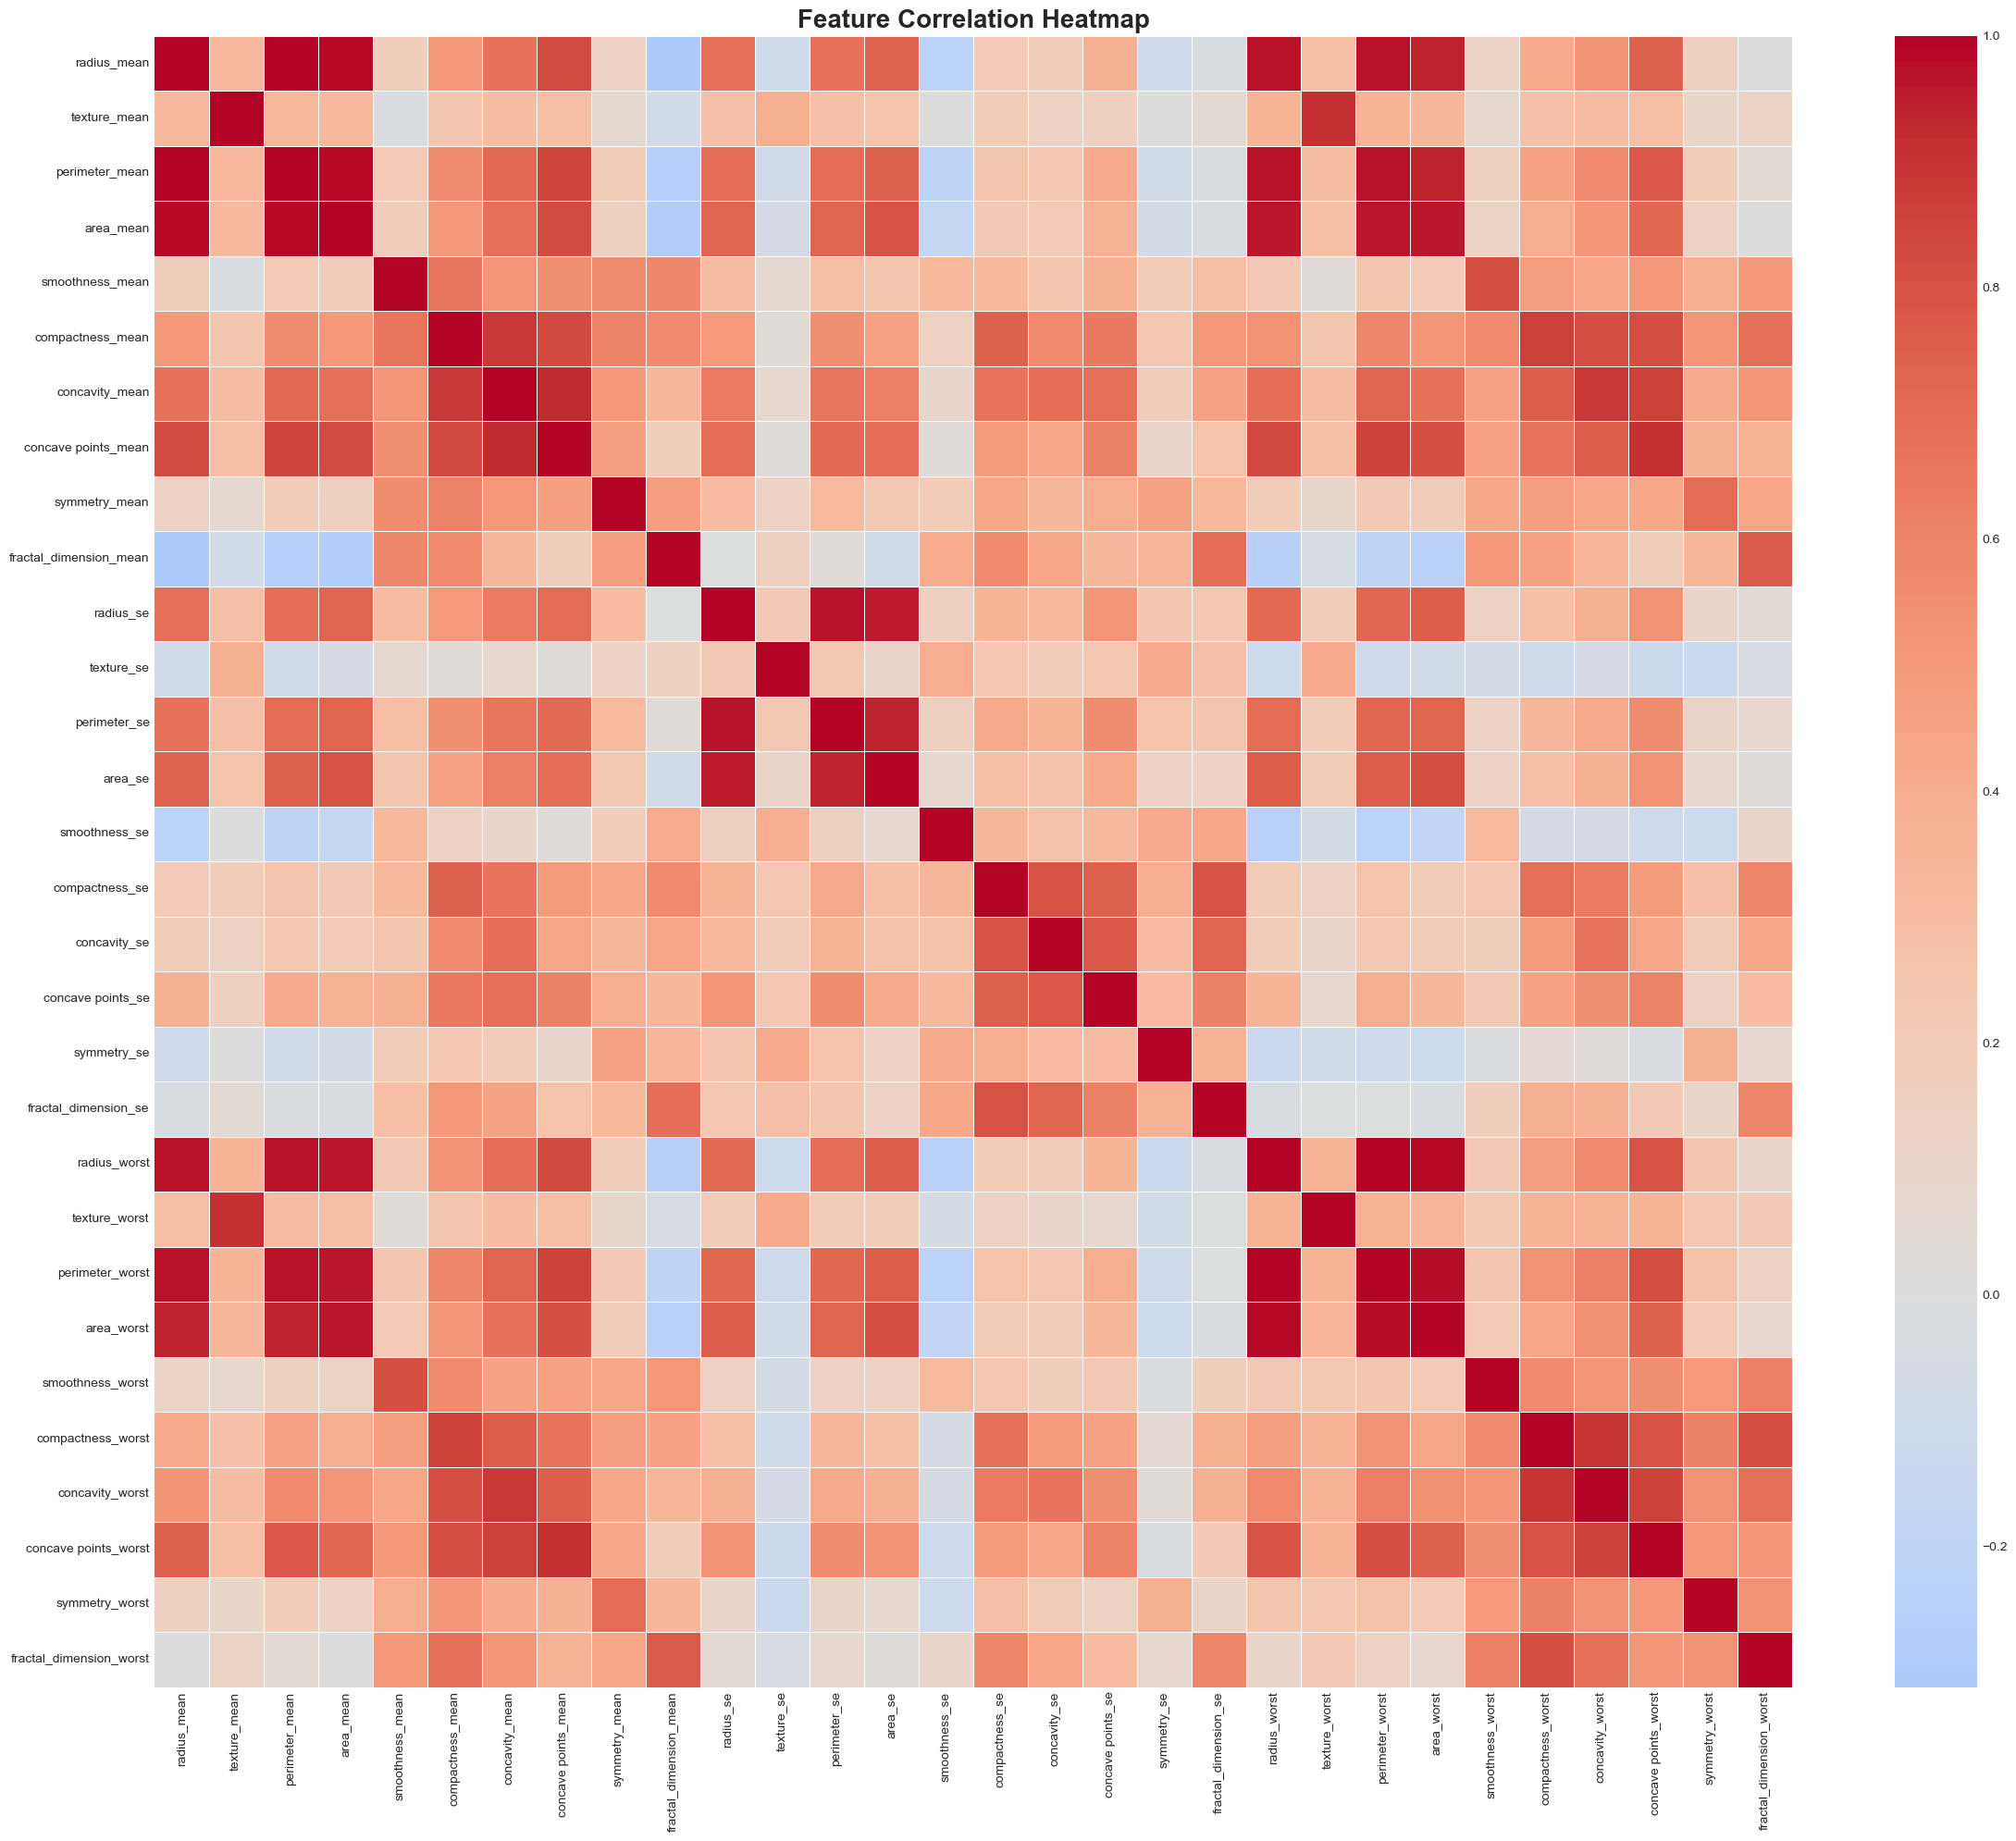

In [7]:
plt.figure(figsize=(24, 20))
sns.heatmap(X.corr(), cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()


**Target Distribution Plot**

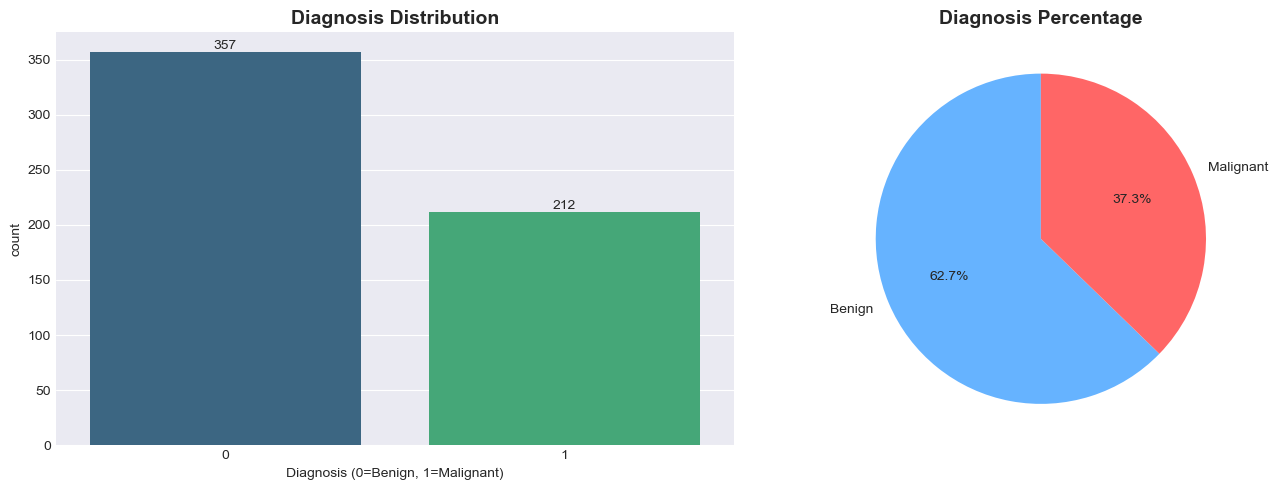

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=y, ax=axes[0], palette='viridis')
axes[0].set_title('Diagnosis Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis (0=Benign, 1=Malignant)')
for container in axes[0].containers:
    axes[0].bar_label(container)

y_counts = y.value_counts()
axes[1].pie(y_counts, labels=['Benign', 'Malignant'], autopct='%1.1f%%', 
            startangle=90, colors=['#66b3ff', '#ff6666'])
axes[1].set_title('Diagnosis Percentage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Box Plots**

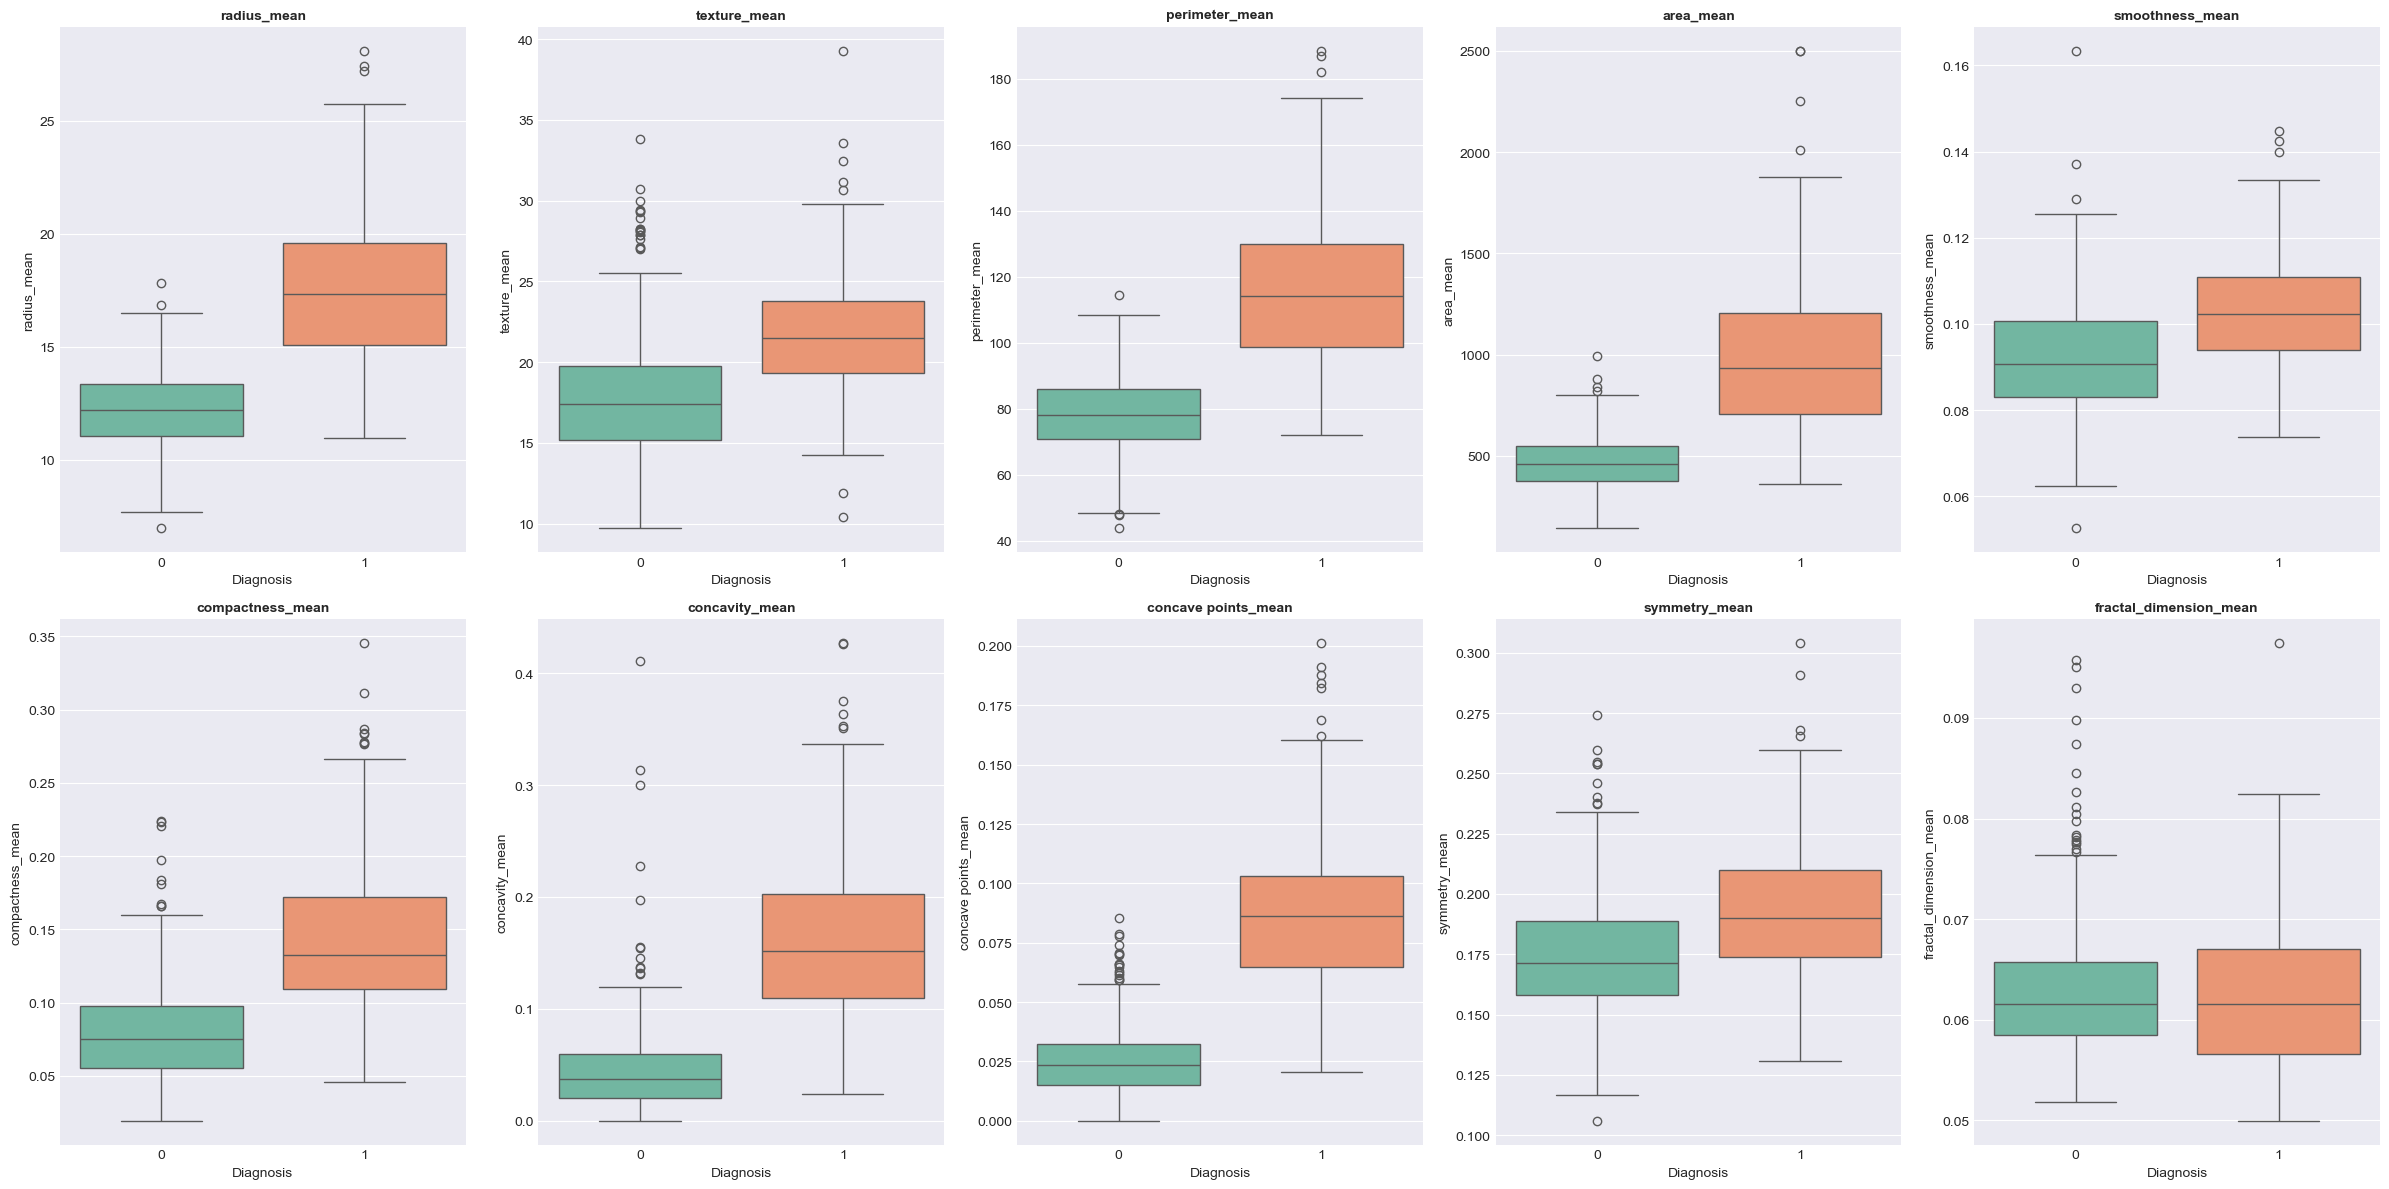

In [9]:
mean_features = [col for col in X.columns if '_mean' in col]
n_cols = 5
n_rows = (len(mean_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 12))
axes = axes.flatten()

for idx, feature in enumerate(mean_features):
    sns.boxplot(x=y, y=X[feature], ax=axes[idx], palette='Set2')
    axes[idx].set_title(feature, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Diagnosis')

for idx in range(len(mean_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


**Feature Scaling**

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Features scaled successfully")


Features scaled successfully


**Train-Test Split**

In [11]:
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {X_train.shape[0]} samples | Testing: {X_test.shape[0]} samples")


Training: 455 samples | Testing: 114 samples


**SMOTE**

In [12]:
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"After SMOTE: {pd.Series(y_train_balanced).value_counts().to_dict()}")


Before SMOTE: {0: 285, 1: 170}
After SMOTE: {1: 285, 0: 285}


**Training Function**

In [13]:
def train_model(X_tr, y_tr, X_te, y_te, model_name, model, param_grid, cv=5):
    print(f"\nTraining {model_name}...")
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    grid.fit(X_tr, y_tr)
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_te)
    y_pred_proba = best_model.predict_proba(X_te)[:, 1] if hasattr(best_model, 'predict_proba') else None
    
    accuracy = accuracy_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    recall = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_pred_proba) if y_pred_proba is not None else None
    
    cv_scores = cross_val_score(best_model, X_tr, y_tr, cv=cv, scoring='accuracy')
    
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    if roc_auc:
        print(f"  ROC-AUC: {roc_auc:.4f} | CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'CV_Mean': cv_scores.mean(),
        'Best_Model': best_model,
        'Predictions': y_pred,
        'Pred_Proba': y_pred_proba
    }


**Train All Models**

In [14]:
model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=10000),
        'params': {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7]}
    },
    'Support Vector Machine': {
        'model': SVC(probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1], 'kernel': ['rbf']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [100, 200, 500], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {'n_estimators': [100, 200, 500], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.3]}
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'params': {'n_estimators': [100, 200, 500], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.3]}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
    }
}

all_results = []
trained_models = {}

for model_name, config in model_configs.items():
    result = train_model(
        X_train_balanced, y_train_balanced,
        X_test, y_test,
        model_name,
        config['model'],
        config['params']
    )
    all_results.append(result)
    trained_models[model_name] = result['Best_Model']



Training Logistic Regression...
  Best Params: {'C': 0.1, 'solver': 'liblinear'}
  Accuracy: 0.9825 | Precision: 0.9762 | Recall: 0.9762 | F1: 0.9762
  ROC-AUC: 0.9980 | CV: 0.9754 (±0.0035)

Training K-Nearest Neighbors...
  Best Params: {'n_neighbors': 5, 'weights': 'distance'}
  Accuracy: 0.9649 | Precision: 0.9750 | Recall: 0.9286 | F1: 0.9512
  ROC-AUC: 0.9777 | CV: 0.9860 (±0.0119)

Training Naive Bayes...
  Best Params: {'var_smoothing': 1e-09}
  Accuracy: 0.9386 | Precision: 0.9730 | Recall: 0.8571 | F1: 0.9114
  ROC-AUC: 0.9911 | CV: 0.9386 (±0.0096)

Training Support Vector Machine...
  Best Params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  Accuracy: 0.9825 | Precision: 1.0000 | Recall: 0.9524 | F1: 0.9756
  ROC-AUC: 0.9980 | CV: 0.9789 (±0.0089)

Training Random Forest...
  Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy: 0.9737 | Precision: 1.0000 | Recall: 0.9286 | F1: 0.9630
  ROC-AUC: 0.9967 | CV: 0.9772 (±0.0205)

Training XGBoo

**Results Comparison**

In [15]:
results_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision': r['Precision'],
    'Recall': r['Recall'],
    'F1_Score': r['F1_Score'],
    'ROC_AUC': r['ROC_AUC'],
    'CV_Mean': r['CV_Mean']
} for r in all_results])

results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison_results.csv', index=False)


                 Model  Accuracy  Precision   Recall  F1_Score  ROC_AUC  CV_Mean
   Logistic Regression  0.982456   0.976190 0.976190  0.976190 0.998016 0.975439
Support Vector Machine  0.982456   1.000000 0.952381  0.975610 0.998016 0.978947
               XGBoost  0.973684   1.000000 0.928571  0.962963 0.995040 0.977193
         Random Forest  0.973684   1.000000 0.928571  0.962963 0.996693 0.977193
              LightGBM  0.964912   1.000000 0.904762  0.950000 0.994378 0.978947
   K-Nearest Neighbors  0.964912   0.975000 0.928571  0.951220 0.977679 0.985965
     Gradient Boosting  0.964912   1.000000 0.904762  0.950000 0.995701 0.971930
           Naive Bayes  0.938596   0.972973 0.857143  0.911392 0.991071 0.938596


**Ensemble Models**

In [16]:
top_3_models = results_df.head(3)['Model'].tolist()
voting_estimators = [(name, trained_models[name]) for name in top_3_models]

voting_clf = VotingClassifier(estimators=voting_estimators, voting='soft', n_jobs=-1)
voting_clf.fit(X_train_balanced, y_train_balanced)

y_pred_voting = voting_clf.predict(X_test)
y_pred_proba_voting = voting_clf.predict_proba(X_test)[:, 1]

print(f"\nVoting Classifier:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_voting):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_voting):.4f}")

stacking_clf = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X_train_balanced, y_train_balanced)

y_pred_stacking = stacking_clf.predict(X_test)
print(f"\nStacking Classifier:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")



Voting Classifier:
  Accuracy: 0.9825
  Precision: 1.0000
  F1-Score: 0.9756

Stacking Classifier:
  Accuracy: 0.9825


**Save Models**

In [19]:
# Create models folder if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')
    print("✓ Created 'models' folder")

# Get the best model from results
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\nSaving models...")

# Save best model
best_model_filename = f"best_model_{best_model_name.replace(' ', '_')}.pkl"
with open(f'models/{best_model_filename}', 'wb') as f:
    pickle.dump(best_model, f)
print(f"Best model saved: {best_model_filename}")

# Save voting classifier
with open('models/voting_classifier.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)
print("Voting classifier saved")

# Save stacking classifier
with open('models/stacking_classifier.pkl', 'wb') as f:
    pickle.dump(stacking_clf, f)
print("Stacking classifier saved")

# Save scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved")

# Save label encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("Label encoder saved")

# Save feature names
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print("Feature names saved")

print("\nAll models saved successfully!")



Saving models...
Best model saved: best_model_Logistic_Regression.pkl
Voting classifier saved
Stacking classifier saved
Scaler saved
Label encoder saved
Feature names saved

All models saved successfully!


In [22]:
os.getcwd()

'C:\\Users\\Admin\\Desktop\\Saad\\ML Internship\\Drive\\ML Aug 25 Day 21 Projects\\PRJ Cancer Prediction'